In [1]:
import os
import tarfile
import urllib.request
import numpy as np
import pandas as pd


In [2]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

In [3]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

In [4]:
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [5]:
''' Each row represents on district - There are 10 attributes
The info() method is useful to get a quick decription of the data in particular the total number of rows.
'''
if __name__ == "__main__":
    fetch_housing_data()
    housing = load_housing_data()
    print(housing.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [6]:
'''There are 20640 instances in this ds - total_bedrooms attribute has only 20433 nonvalues. 207 districts are missing this feature.
All atributes are numerical, expect ocean_proximity field. It can hold any type of object in the python object. The top five rows where repetitive - means its
catergorical attribute'''
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
'''standard deviation - measures how dispersed the values are'''
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
import matplotlib.pyplot as plt

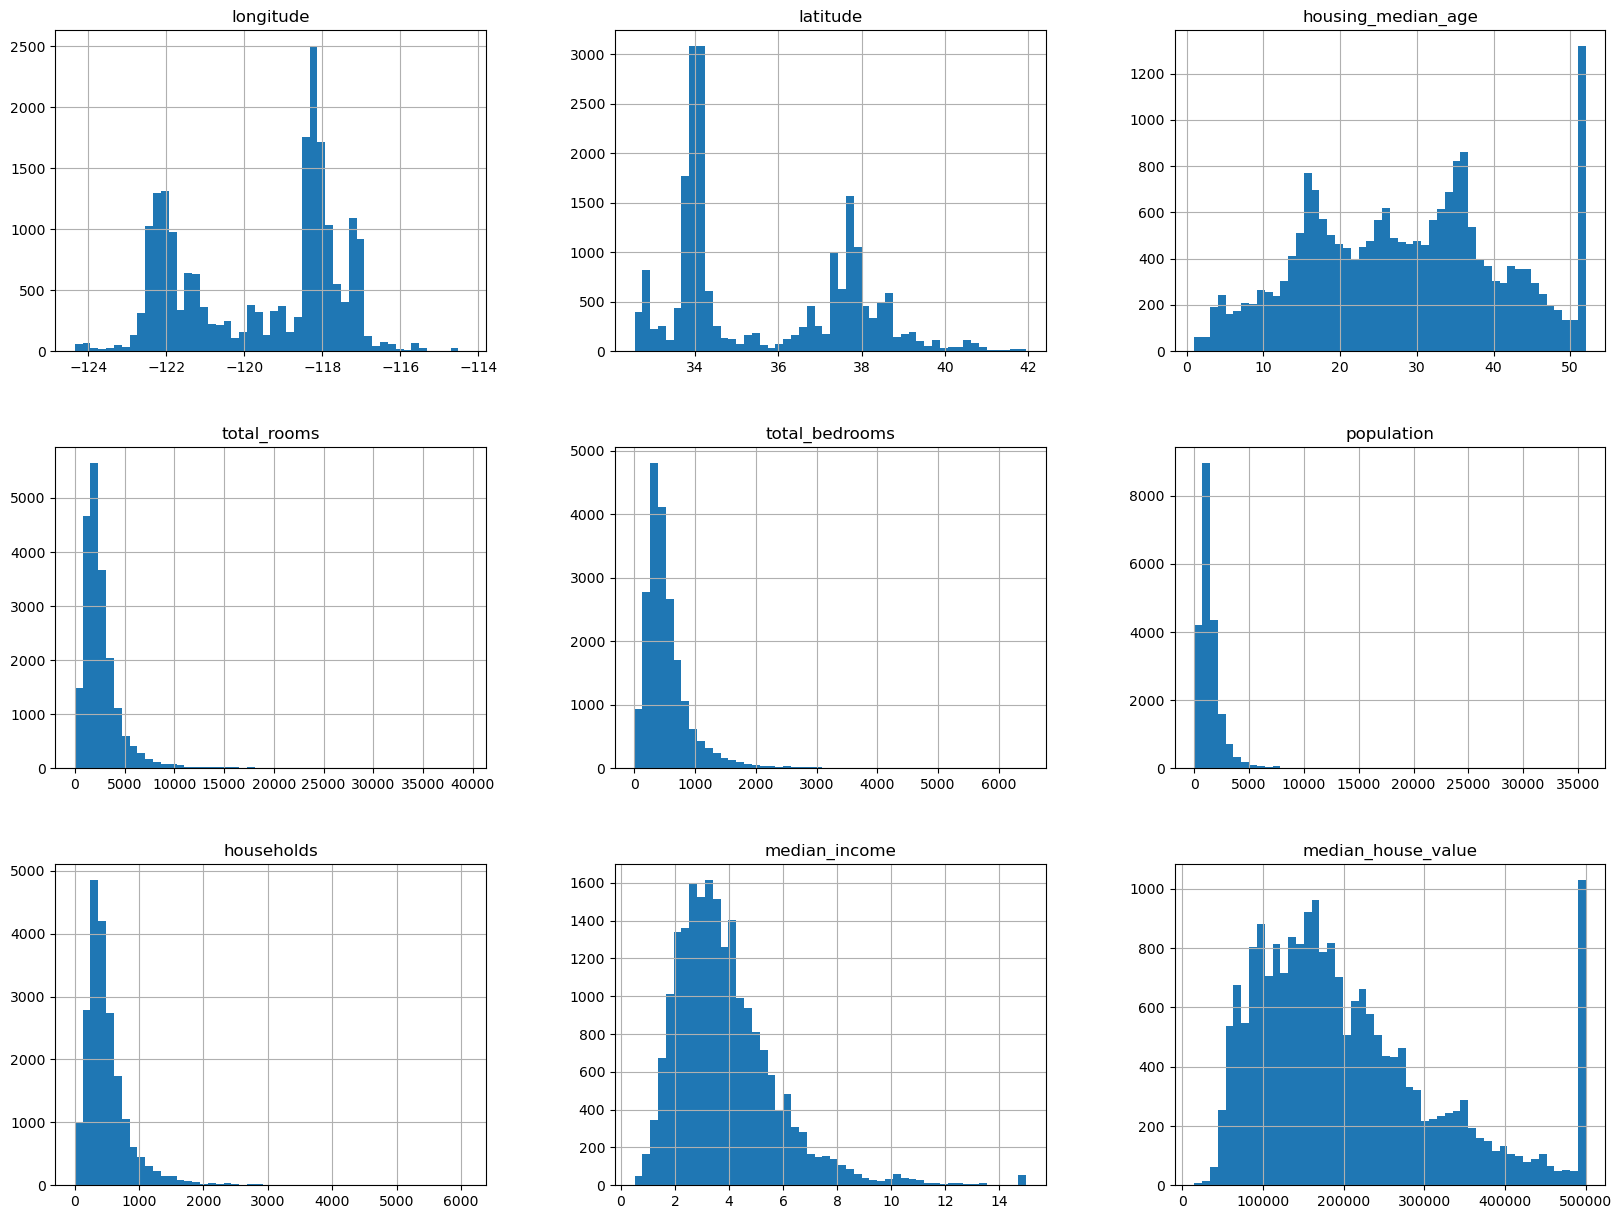

In [10]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [11]:
# creating a test set
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indicies = shuffled_indices[test_set_size:]
    return data.iloc[train_indicies],data.iloc[test_indices]

In [12]:
train_set, test_set = split_train_test(housing, 0.2)
len(train_set)

16512

In [13]:
len(test_set)

4128

In [14]:
from zlib import crc32

In [15]:
def test_set_check(indentifier, test_ratio):
    return crc32(np.int64(indentifier)) & 0xffffffff < test_ratio * 2**32 # pyright: ignore[reportArgumentType]

In [16]:
def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [17]:
# adds an `index` column
housing_with_id = housing.reset_index()
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [18]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [19]:
from sklearn.model_selection import train_test_split

d:\miniforge\envs\ml-nlp\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.4)
  from scipy.sparse import csr_matrix, issparse


In [20]:
train_set, test_set = train_test_split(housing, test_size = 0.2, random_state=42)

In [21]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0,1.5,3.0,4.5,6.,np.inf],
                               labels=[1,2,3,4,5])

<Axes: >

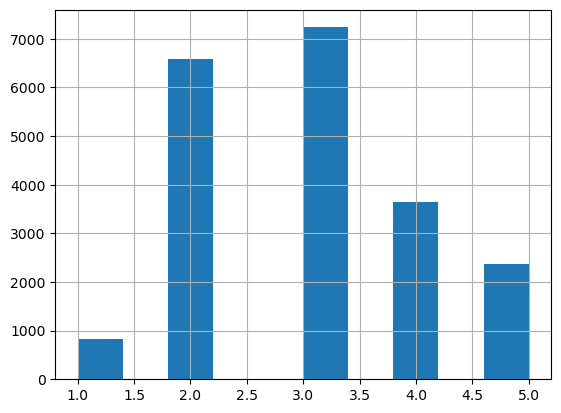

In [22]:
housing["income_cat"].hist()

In [23]:
from sklearn.model_selection import StratifiedShuffleSplit

In [24]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [25]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [26]:
for set_ in(strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [27]:
housing = strat_test_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

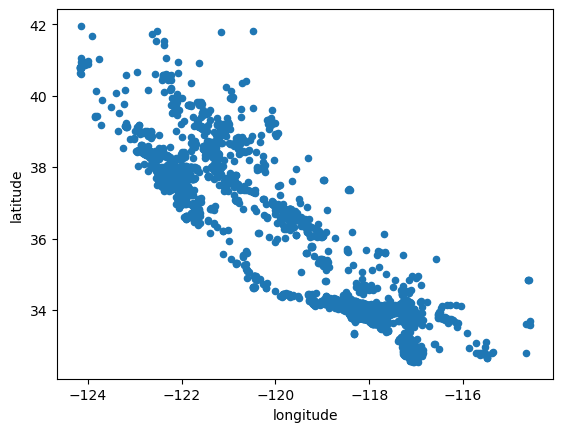

In [28]:
housing.plot(kind="scatter", x="longitude", y="latitude")

<Axes: xlabel='longitude', ylabel='latitude'>

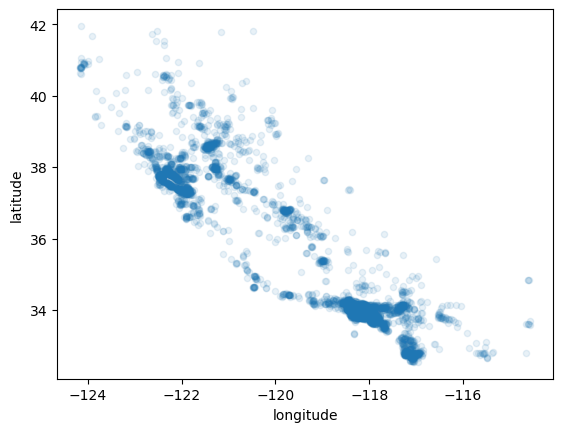

In [29]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

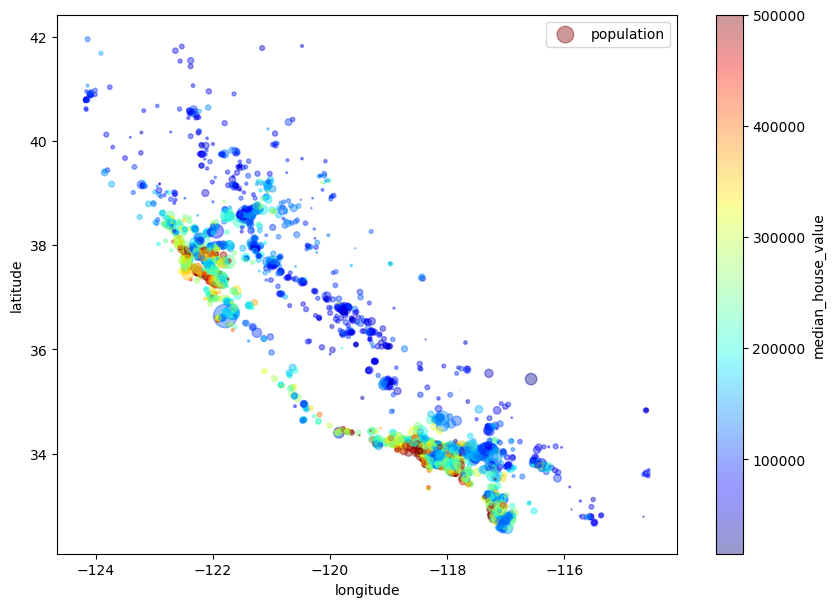

In [30]:
from matplotlib import colorbar


housing.plot(kind="scatter",x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()

In [31]:
corr_matrix = housing.corr(numeric_only=True)

In [32]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.691867
total_rooms           0.131296
housing_median_age    0.071210
households            0.070947
total_bedrooms        0.057247
population           -0.016164
longitude            -0.039848
latitude             -0.150336
Name: median_house_value, dtype: float64

In [33]:
from pandas.plotting import scatter_matrix

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

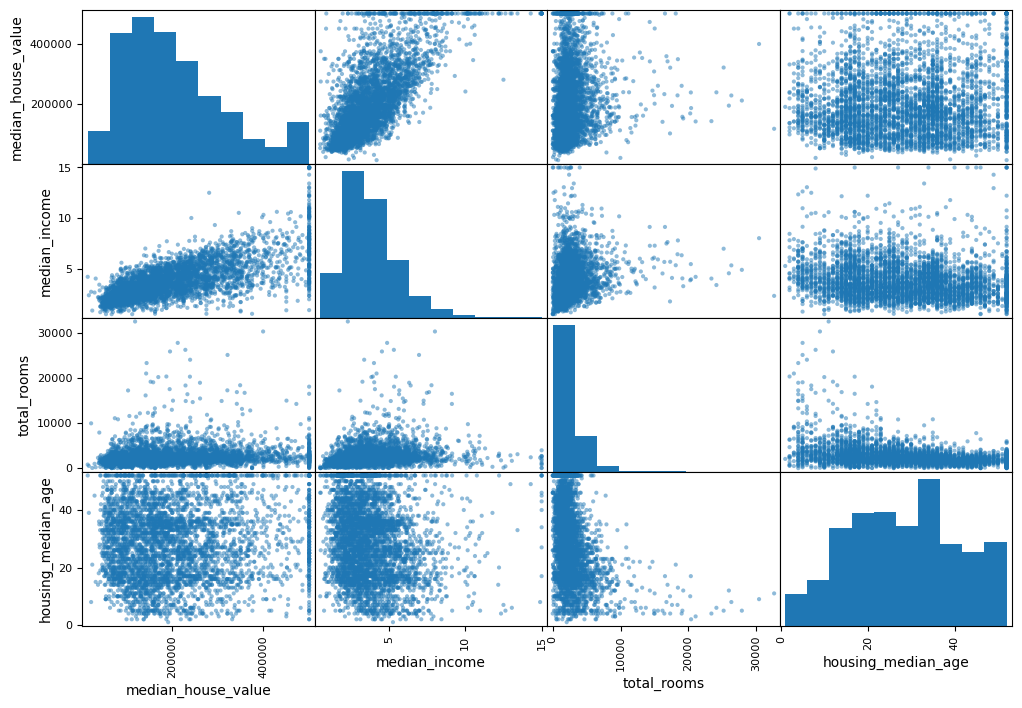

In [34]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

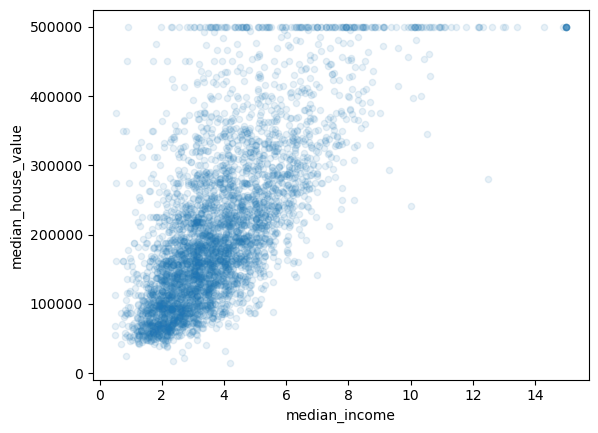

In [35]:
# Correlation scatterplot
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)

In [36]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"] =  housing["population"]/housing["households"]

In [37]:
corr_matrix = housing.corr(numeric_only=True)

In [38]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.691867
rooms_per_household         0.192731
total_rooms                 0.131296
housing_median_age          0.071210
households                  0.070947
total_bedrooms              0.057247
population                 -0.016164
longitude                  -0.039848
population_per_household   -0.134999
latitude                   -0.150336
bedrooms_per_room          -0.240481
Name: median_house_value, dtype: float64

In [39]:
# Preparing Data for the machine learning algorithms

In [40]:
# Revert a clean training set(by coping strat_train_set)
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [41]:
# Data cleaning
'''
1. Get rid of the corresponding districts
2. Get rid of the whole attribute
3. Set the values to some value(zero, the mean, the median)
'''
median = housing["total_bedrooms"].median() # option 3
housing["total_bedrooms"].fillna(median, inplace = True)

C:\Users\Antonio Alvarez\AppData\Local\Temp\ipykernel_61120\65569013.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median, inplace = True)


In [42]:
from sklearn.impute import SimpleImputer

In [43]:
imputer = SimpleImputer(strategy="median")

In [44]:
#median can only be comuted on numerical attributes
housing_num = housing.drop("ocean_proximity", axis=1)

In [45]:
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [46]:
# imputer is simply computed the median of each attribute and store the result in statisitics_instance variable - only total_bedrooms had missing values
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [47]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [48]:
X = imputer.transform(housing_num)

In [49]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index) # type: ignore

In [50]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [51]:
from sklearn.preprocessing import OrdinalEncoder

In [52]:
ordinal_encoder = OrdinalEncoder()

In [53]:
housing_cat_encoder = ordinal_encoder.fit_transform(housing_cat)

In [54]:
# limited number of possible values - which can represent a category(categorical attributes)
housing_cat_encoder[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [55]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [56]:
''' one attribute equal to 1 when the cate‐
gory is “<1H OCEAN” (and 0 otherwise), another attribute equal to 1 when the cate‐
gory is “INLAND” (and 0 otherwise), and so on. This is called one-hot encoding'''
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [57]:
housing_cat_1hot.toarray() # type: ignore

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [58]:
# get list of encoder's categories
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [59]:
# Custom Transformers
from sklearn.base import BaseEstimator, TransformerMixin

In [60]:
rooms_ix, bedrooms_ix, population_ix, households_ix = 3,4,5,6

In [61]:
# this transformer has one hyperparameter
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, 
                     bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

In [62]:
# Feature scaling is important for transformers
'''Two common ways to get all attributes to have the same scale: min-max scaling and standardization'''
# min-max is called normalization
# Standardization first subtracts the mean value(standardized values always a have a zero mean) and devides by the standard deviation so the resulting distribution has a unit variance


'Two common ways to get all attributes to have the same scale: min-max scaling and standardization'

In [63]:
# Transformation Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [64]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
('attribs_adder', CombinedAttributesAdder()),
('std_scaler', StandardScaler())
])

housing_num_tr = num_pipeline.fit_transform(housing_num)

In [65]:

from sklearn.compose import ColumnTransformer

In [66]:
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]


In [67]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])
'''when calling a pipeline's fit() method, it calls fit_transform() sequentially on all transformers, pasing the output of each call
as the parameter to next call until it reaches the final estimator, for which it calls the fit() method'''
housing_prepared = full_pipeline.fit_transform(housing)

In [68]:
# Selecting and Training a model
from sklearn.linear_model import LinearRegression

In [69]:
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predicitions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))

Predicitions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [71]:
from sklearn.metrics import mean_squared_error

In [72]:
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

In [73]:
# DecisionTreeRegressor is a powerful model , capable of finding complex nonlinear relationships 
from sklearn.tree import DecisionTreeRegressor

In [74]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [75]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_mse = np.sqrt(tree_mse)
tree_mse

np.float64(0.0)

In [76]:
# Using Cross-Validation
from sklearn.model_selection import cross_val_score

In [77]:
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
 scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)



In [78]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard devivation:", scores.std())
display_scores(tree_rmse_scores)

Scores: [73066.52878281 69757.24829716 68283.681384   71321.20854651
 69941.92369075 77755.54564655 70679.9281029  73277.76734755
 68859.88380222 71028.10317487]
Mean: 71397.18187753264
Standard devivation: 2614.335097435453


In [79]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv = 10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247066
Standard devivation: 2880.328209818075


In [80]:
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np

In [81]:
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
forest_rmse_scores = np.sqrt(-cross_val_score(
    forest_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
))

In [83]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std)

In [84]:
# show the scores
display_scores(forest_rmse_scores)

Scores: [51368.58575675 49205.31995809 46945.85889136 52070.99727546
 47093.88983791 52115.72319042 52509.31178677 50090.81206151
 48899.88108891 54047.75603028]
Mean: 50434.81358774648
Standard deviation: <built-in method std of numpy.ndarray object at 0x000002B4ECB1D6B0>


In [86]:
# Fine tunning the model
'''Grid Search we tell it which hyperparamters we want and what values to try out'''
from sklearn.model_selection import GridSearchCV

In [87]:
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
forest_reg = RandomForestRegressor()

In [89]:
grid_search = GridSearchCV(forest_reg, param_grid, cv = 5, scoring ='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [90]:
# param_grid tells Scikit-Learn to frist evaluate all combinations of n_estimators and max_features hyperparameters mean
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [93]:
grid_search.best_estimator_


,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# The RMSE score for this combination is 49,682 (fine-tunned)
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

65206.329288571214 {'max_features': 2, 'n_estimators': 3}
55432.92214142996 {'max_features': 2, 'n_estimators': 10}
52744.56964911634 {'max_features': 2, 'n_estimators': 30}
60586.019627829264 {'max_features': 4, 'n_estimators': 3}
52699.253417777516 {'max_features': 4, 'n_estimators': 10}
50228.75538988486 {'max_features': 4, 'n_estimators': 30}
58800.87781384172 {'max_features': 6, 'n_estimators': 3}
52260.645855081064 {'max_features': 6, 'n_estimators': 10}
49894.37436070135 {'max_features': 6, 'n_estimators': 30}
58998.05761515951 {'max_features': 8, 'n_estimators': 3}
52222.85467109936 {'max_features': 8, 'n_estimators': 10}
50154.11402845067 {'max_features': 8, 'n_estimators': 30}
62466.20769620991 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54415.79283297601 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60041.489790490945 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52950.76701987661 {'bootstrap': False, 'max_features': 3, 'n_estimators

In [95]:
'''Ensemble Methods are a different way to fine-tun your system by combining the odles that perform best'''
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([7.12868973e-02, 6.93712834e-02, 4.11790628e-02, 1.67890285e-02,
       1.62228860e-02, 1.69167954e-02, 1.68216609e-02, 3.29490524e-01,
       5.38526412e-02, 1.09310676e-01, 7.73632091e-02, 6.96965520e-03,
       1.67626030e-01, 7.86167334e-05, 2.65413434e-03, 4.06689905e-03])

In [96]:
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.3294905241832699), 'median_income'),
 (np.float64(0.16762603029578943), 'INLAND'),
 (np.float64(0.10931067567770233), 'pop_per_hhold'),
 (np.float64(0.07736320905176064), 'bedrooms_per_room'),
 (np.float64(0.07128689732009656), 'longitude'),
 (np.float64(0.06937128335229804), 'latitude'),
 (np.float64(0.053852641212827755), 'rooms_per_hhold'),
 (np.float64(0.04117906276586057), 'housing_median_age'),
 (np.float64(0.016916795390213502), 'population'),
 (np.float64(0.016821660925014314), 'households'),
 (np.float64(0.016789028472119782), 'total_rooms'),
 (np.float64(0.016222886027038412), 'total_bedrooms'),
 (np.float64(0.006969655201647019), '<1H OCEAN'),
 (np.float64(0.004066899046150449), 'NEAR OCEAN'),
 (np.float64(0.0026541343448568985), 'NEAR BAY'),
 (np.float64(7.861673335432717e-05), 'ISLAND')]

In [98]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)

final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [99]:
# check how precise it is 
from scipy import stats

In [100]:
confidence = 0.95
squared_errors = (final_predictions - y_test) **2
np.sqrt(stats.t.interval(confidence, len(squared_errors)-1, 
                         loc=squared_errors.mean(), scale=stats.sem(squared_errors)))

array([45978.20614736, 49870.71264737])